In [ ]:
import pandas as pd

# Load the merged dataset
df = pd.read_csv("merged_reviews_with_metadata.csv")

# Count unique parent_asin values
unique_products = df['parent_asin'].nunique()

print(f"✅ Total unique products (parent_asin): {unique_products}")


✅ Total unique products (parent_asin): 7068


In [ ]:
import pandas as pd

# Load your merged dataset
df = pd.read_csv("merged_reviews_with_metadata.csv")


# ✅ Extended list of skincare keywords
skincare_keywords = [
    # Cleansers & face wash
    "cleanser", "face wash", "cleansing balm", "facial cleanser", "micellar water",

    # Moisturizers & creams
    "moisturizer", "hydrating cream", "face cream", "night cream", "day cream",
    "skin cream", "gel cream", "hydrating lotion", "body lotion", "face lotion",

    # Serums & treatments
    "serum", "vitamin c", "niacinamide", "hyaluronic acid", "retinol", "peptides",
    "anti-aging", "brightening serum", "firming serum", "skin serum",

    # Sunscreens
    "sunscreen", "spf", "sun cream", "uv protection", "broad spectrum",

    # Acne & spot treatments
    "acne", "spot treatment", "blemish", "zit", "pimple", "blackhead", "whitehead",
    "acne cream", "acne patch", "acne treatment",

    # Toners, mists, essences
    "toner", "essence", "facial mist", "hydrating toner", "clarifying toner",

    # Eye care
    "eye cream", "under eye", "eye gel", "dark circle", "puffy eyes",

    # Exfoliators & masks
    "exfoliant", "exfoliator", "chemical exfoliant", "scrub", "peel",
    "clay mask", "sheet mask", "face mask", "overnight mask", "aha", "bha", "salicylic acid", "glycolic acid",

    # Skin repair / barrier
    "barrier repair", "ceramide", "soothing gel", "repair cream", "eczema", "psoriasis",

    # General descriptors
    "skincare", "skin care", "facial", "dermatologist recommended", "sensitive skin", "hydrating", "non-comedogenic"
]

# ✅ Combine product title and description for keyword matching
df['combined_text'] = (
    df['product_title'].fillna('').str.lower() + " " +
    df['product_description'].fillna('').astype(str).apply(lambda x: ' '.join(x).lower())
)

# ✅ Filter the DataFrame to include only skincare-related rows
skincare_df = df[df['combined_text'].str.contains('|'.join(skincare_keywords), na=False)]

# ✅ Preview results
print(f"✅ Skincare reviews extracted: {len(skincare_df)}")
print(skincare_df[['product_title', 'rating']].head())

# ✅ Save filtered dataset
skincare_df.to_csv("skincare_reviews_filtered.csv", index=False)


✅ Skincare reviews extracted: 2012
                                        product_title  rating
6   Disposable Facial Cotton Tissue, 100PCS Cotton...       5
8   NIRA Skincare Laser & Serum Bundle - Includes ...       5
10  Orange Peel Nature's Cleanse Facial Scrub - by...       3
11  OGANA CELL Peptide Concentrating Amazing Lotio...       5
14  Hanhoo Red pomegranate 6pcs Skin Care Set (6pc...       5


**Descriptive Analysis of sample distribution (Amazon reviews)**

In [ ]:
import pandas as pd
import numpy as np

# === Load the data ===
df = pd.read_csv("skincare_reviews_filtered.csv")

# Clean column names if needed
df.columns = df.columns.str.strip().str.lower()

# Ensure expected columns exist
required_cols = ["rating", "text", "verified_purchase", "helpful_vote", "product_title", "parent_asin"]
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Missing column: {col}")

# Convert data types
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["helpful_vote"] = pd.to_numeric(df["helpful_vote"], errors="coerce").fillna(0).astype(int)
df["verified_purchase"] = df["verified_purchase"].astype(str).str.lower().map({"true": True, "false": False}).fillna(False)
df["text"] = df["text"].fillna("").astype(str)
df["review_length_words"] = df["text"].str.split().str.len()

N = len(df)

In [ ]:
print(" 2.1 Review & Product Distribution")
total_reviews = N
unique_products = df["parent_asin"].nunique()
top_products = (
    df.groupby(["parent_asin", "product_title"])
      .size()
      .reset_index(name="review_count")
      .sort_values("review_count", ascending=False)
      .head(10)
)
print(f"Total reviews: {total_reviews}")
print(f"Unique products: {unique_products}")
print("\nTop 10 products by review count:")
print(top_products)

 2.1 Review & Product Distribution
Total reviews: 2012
Unique products: 1312

Top 10 products by review count:
     parent_asin                                      product_title  \
749   B07TK15BQQ  R-NEU 200 Cotton Rounds, 100% Natural Turkish ...   
518   B079NV9PBG  Yes To Face Wipes for Women and Men, Sensitive...   
87    B00J7QCNDU  DMSO Cream with Aloe Vera, 4 oz - Rose Scented...   
99    B00KCTER3U  Retinol Face Moisturizer Cream Natural Facial ...   
1130  B08XMBHL8C  MARLOWE. 002 Extra Moisturizing Body Lotion 15...   
279   B01BJCLNIA  Organic Castor Oil - Boost Hair Growth for Hai...   
1301  B0BMWQQR9W  Nail-Aid Ceramide Extreme Thickener - Nail Str...   
1149  B0914JBBTV  Bioré J-Beauty Makeup Removing Moisturizing Cl...   
178   B00YI0XFUU  Mineral Springs Luxuries Exfoliating Loofah Ba...   
128   B00NT0AR7E                           OZNaturals Retinol Serum   

      review_count  
749             19  
518             13  
87              10  
99              10  
11

**Descriptive Analysis - Survey (Primary data)**



In [ ]:
import pandas as pd

# Load the survey file
file_path = "Survey_Likert_Mapped (1).xlsx"
df = pd.read_excel(file_path)

# Clean column names
df.columns = df.columns.str.strip()


# Columns to analyze
columns_to_analyze = [
    "What is your age group?",
    "How often do you purchase skincare products?"
]

# Create an empty dictionary to store results
tables = {}

# Loop through columns and calculate frequency & percentage
for col in columns_to_analyze:
    freq = df[col].value_counts(dropna=False).reset_index()
    freq.columns = [col, "Frequency"]
    freq["Percentage"] = (freq["Frequency"] / freq["Frequency"].sum() * 100).round(2)
    tables[col] = freq

# Display results
for col, table in tables.items():
    print(f" {col}")
    print(table.to_string(index=False))

 What is your age group?
What is your age group?  Frequency  Percentage
                  18ñ24        154       50.16
                  25ñ34        119       38.76
                  35ñ44         21        6.84
                   †45+          9        2.93
                    45+          4        1.30
 How often do you purchase skincare products?
How often do you purchase skincare products?  Frequency  Percentage
                                     Monthly        110       35.83
                                      Weekly         92       29.97
                            Every 2ñ3 months         71       23.13
                                      Rarely         34       11.07


**ANALYSIS WITH MODERATORS AND CONTROLS _ UPDATED**

Distilbert to add sentiment score to amazon review

In [ ]:
# Install transformers if not already installed
!pip install transformers torch tqdm

import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TextClassificationPipeline
from tqdm import tqdm

# Load dataset
amazon = pd.read_csv("skincare_reviews_filtered.csv")

# Load DistilBERT pre-trained model for sentiment
MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
clf = TextClassificationPipeline(model=model, tokenizer=tokenizer, return_all_scores=True, truncation=True)

# --- helper functions ---
def chunk_text_words(text, max_words=180):
    words = str(text).split()
    if len(words) <= max_words:
        return [str(text)]
    return [" ".join(words[i:i+max_words]) for i in range(0, len(words), max_words)]

def sst2_score(text):
    """Return mean (P(pos)-P(neg)) across chunks in [-1, +1]."""
    chunks = chunk_text_words(text, max_words=180)
    outs = clf(chunks, batch_size=32)
    vals = []
    for out in outs:
        pos = next(x["score"] for x in out if x["label"].upper().startswith("POS"))
        neg = next(x["score"] for x in out if x["label"].upper().startswith("NEG"))
        vals.append(pos - neg)
    return float(np.mean(vals)) if len(vals) else np.nan

# Detect the review text column
text_col = None
for c in amazon.columns:
    if any(k in c.lower() for k in ["review", "text", "body", "content"]):
        text_col = c
        break

# Compute sentiment scores
if text_col:
    tqdm.pandas(desc="Scoring sentiment with DistilBERT")
    amazon["Sentiment_score"] = amazon[text_col].progress_apply(sst2_score)
else:
    amazon["Sentiment_score"] = np.nan

# Save new dataset
amazon.to_csv("skincare_reviews_with_sentiment.csv", index=False)
print("✅ Sentiment scores added and saved to skincare_reviews_with_sentiment.csv")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 794.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 800.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 25.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Device set to use cpu
/usr/local/lib/python3.11/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
Scoring sentiment with DistilBERT: 100%|██████████| 2012/2012 [06:10<00:00,  5.43it/s]

✅ Sentiment scores added and saved to skincare_reviews_with_sentiment.csv


**Descriptive Analytics - Survey and Amazon review**

In [ ]:
import pandas as pd
amazon = pd.read_csv("skincare_reviews_with_sentiment.csv")
print(amazon.columns.tolist())


['rating', 'title', 'text', 'parent_asin', 'helpful_vote', 'verified_purchase', 'product_title', 'product_description', 'combined_text', 'Sentiment_score']


In [ ]:
import pandas as pd
amazon = pd.read_csv("Survey_Likert_Mapped_converted_v2.csv")
print(amazon.columns.tolist())

['Review reliance', 'Trust detailed reviews', 'Trust verified reviews', 'Avoidance after negative review', 'Trust verified and detailed.', 'Age_num', 'Purchase_frequency_num']


In [ ]:
# =====================================================
# Descriptive Statistics (Survey + Amazon Data)
# Includes quantiles, skewness, and kurtosis
# -----------------------------------------------------
# Inputs:
#   - Survey_Likert_Mapped_converted_v2.csv
#   - skincare_reviews_with_sentiment.csv
#
# Output:
#   - Descriptive_Stats.csv
#   - Printed table in console
# =====================================================

import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

# ---------- Helper function ----------
def descriptive_stats(df, name_prefix=""):
    desc = pd.DataFrame({
        "N": df.count(),
        "Mean": df.mean(),
        "SD": df.std(ddof=1),
        "Min": df.min(),
        "25%": df.quantile(0.25),
        "50%": df.median(),
        "75%": df.quantile(0.75),
        "Max": df.max(),
        "Skewness": df.apply(lambda x: skew(x.dropna())),
        "Kurtosis": df.apply(lambda x: kurtosis(x.dropna(), fisher=False))  # fisher=False => normal=3
    }).round(3)

    desc.index = [f"{name_prefix}{c}" for c in desc.index]  # optional prefix
    return desc.reset_index().rename(columns={"index": "Variable"})

# ---------- Load Survey ----------
survey = pd.read_csv("Survey_Likert_Mapped_converted_v2.csv")

survey_vars = [
    "Review reliance",
    "Trust detailed reviews",
    "Trust verified reviews",
    "Trust verified and detailed.",
    "Avoidance after negative review",
    "Age_num",
    "Purchase_frequency_num"
]

survey_stats = descriptive_stats(survey[survey_vars], name_prefix="Survey: ")

# ---------- Load Amazon ----------
amazon = pd.read_csv("skincare_reviews_with_sentiment.csv")

# Clean / construct needed variables
amazon["helpful_vote"] = pd.to_numeric(amazon["helpful_vote"], errors="coerce")
amazon["rating"] = pd.to_numeric(amazon["rating"], errors="coerce")
amazon["verified_purchase"] = amazon["verified_purchase"].astype(str).str.lower().isin(
    ["1","true","yes","y"]).astype(int)

text_col = "text" if "text" in amazon.columns else "combined_text"
amazon["review_length_words"] = amazon[text_col].astype(str).str.split().apply(len)
amazon["Sentiment_score"] = pd.to_numeric(amazon["Sentiment_score"], errors="coerce")

amazon_vars = [
    "helpful_vote",
    "rating",
    "verified_purchase",
    "review_length_words",
    "Sentiment_score"
]

amazon_stats = descriptive_stats(amazon[amazon_vars], name_prefix="Amazon: ")

# ---------- Combine ----------
all_stats = pd.concat([survey_stats, amazon_stats], ignore_index=True)

# ---------- Save ----------
all_stats.to_csv("Descriptive_Stats.csv", index=False)

# ---------- Print ----------
print("✅ Descriptive Statistics Table (Survey + Amazon)")
print(all_stats.to_string(index=False))


✅ Descriptive Statistics Table (Survey + Amazon)
                               Variable    N   Mean     SD  Min    25%    50%    75%    Max  Skewness  Kurtosis
                Survey: Review reliance  307  4.293  0.828  1.0  4.000  4.000  5.000    5.0    -1.109     4.212
         Survey: Trust detailed reviews  307  4.143  0.866  1.0  4.000  4.000  5.000    5.0    -0.733     3.020
         Survey: Trust verified reviews  307  4.186  0.776  1.0  4.000  4.000  5.000    5.0    -0.544     2.692
   Survey: Trust verified and detailed.  307  3.932  0.791  1.0  4.000  4.000  4.000    5.0    -0.909     5.069
Survey: Avoidance after negative review  307  3.798  0.942  1.0  3.000  4.000  4.000    5.0    -0.717     3.388
                        Survey: Age_num  307 26.682  7.002 21.0 21.000 21.000 29.500   47.5     1.296     4.333
         Survey: Purchase_frequency_num  307  2.140  0.965  1.0  1.000  2.000  3.000    4.0     0.417     2.182
                   Amazon: helpful_vote 2012  1.003  5.

**Correlation for both data survey and amazon data.**

In [ ]:
# ============================================================
# Descriptive Statistics + Correlation Matrix (Survey & Amazon)
# Lower-triangle format (like journal tables)
# ------------------------------------------------------------
# Inputs:
#   - Survey_Likert_Mapped_converted_v2.csv
#   - skincare_reviews_with_sentiment.csv
#
# Outputs:
#   - Correlation_Report.xlsx   (two sheets: Survey, Amazon)
#   - Survey_Corr.csv
#   - Amazon_Corr.csv
#
# Notes:
# - Correlations are Pearson (two-tailed). Significance stars:
#       * p < .05,  ** p < .01,  *** p < .001
# - Binary variables are treated numerically (0/1).
# ============================================================

import numpy as np
import pandas as pd
from scipy import stats

# ---------- Helpers ----------
def corr_with_pstars(df):
    """
    Return two DataFrames:
      1) r matrix with significance stars appended (lower triangle only)
      2) raw numeric r matrix (no stars)
    """
    cols = df.columns
    r_mat = pd.DataFrame(np.nan, index=cols, columns=cols, dtype=float)
    p_mat = pd.DataFrame(np.nan, index=cols, columns=cols, dtype=float)

    for i, a in enumerate(cols):
        for j, b in enumerate(cols):
            x = pd.to_numeric(df[a], errors="coerce")
            y = pd.to_numeric(df[b], errors="coerce")
            mask = x.notna() & y.notna()
            if mask.sum() >= 3:
                r, p = stats.pearsonr(x[mask], y[mask])
            else:
                r, p = np.nan, np.nan
            r_mat.loc[a, b] = r
            p_mat.loc[a, b] = p

    def star(p):
        if pd.isna(p):
            return ""
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return ""

    # Build pretty matrix with stars (lower triangle only)
    pretty = r_mat.copy().astype(object)
    for i in range(len(cols)):
        for j in range(len(cols)):
            if i == j:
                pretty.iat[i, j] = "—"
            elif j > i:   # blank out upper triangle
                pretty.iat[i, j] = ""
            else:
                r = r_mat.iat[i, j]
                s = star(p_mat.iat[i, j])
                pretty.iat[i, j] = "" if pd.isna(r) else f"{r:.3f}{s}"

    return pretty, r_mat

def mean_sd(df):
    m = df.apply(pd.to_numeric, errors="coerce").mean()
    s = df.apply(pd.to_numeric, errors="coerce").std(ddof=1)
    return m.round(3), s.round(3)

def assemble_table(df_vars, var_order=None):
    """Create a combined table: Mean, SD, then correlation matrix (lower triangle)."""
    if var_order is None:
        var_order = list(df_vars.columns)
    df_vars = df_vars[var_order].copy()

    # Descriptives
    M, S = mean_sd(df_vars)
    desc = pd.DataFrame({"Variable": var_order, "Mean": M[var_order].values, "SD": S[var_order].values})

    # Correlations (with stars)
    corr_pretty, _ = corr_with_pstars(df_vars[var_order])
    corr_pretty.insert(0, "Variable", var_order)

    # Merge
    out = desc.merge(corr_pretty, on="Variable")
    return out

# ---------- Paths ----------
SURVEY_CSV  = "Survey_Likert_Mapped_converted_v2.csv"
AMAZON_CSV  = "skincare_reviews_with_sentiment.csv"
OUT_XLSX    = "Correlation_Report.xlsx"

# ---------- SURVEY ----------
survey = pd.read_csv(SURVEY_CSV)

survey_vars = {
    "Review reliance": "Review reliance",
    "Trust detailed reviews": "Trust detailed reviews",
    "Trust verified reviews": "Trust verified reviews",
    "Trust verified and detailed.": "Trust verified and detailed.",
    "Avoidance after negative review": "Avoidance after negative review",
    "Age_num": "Age_num",
    "Purchase_frequency_num": "Purchase_frequency_num",
}

survey_df_vars = survey[list(survey_vars.values())].copy()
survey_order = list(survey_vars.values())
survey_table = assemble_table(survey_df_vars, survey_order)

# ---------- AMAZON ----------
amazon = pd.read_csv(AMAZON_CSV)

amazon["helpful_vote"] = pd.to_numeric(amazon.get("helpful_vote"), errors="coerce")
amazon["rating"] = pd.to_numeric(amazon.get("rating"), errors="coerce")
amazon["verified_purchase"] = amazon.get("verified_purchase").astype(str).str.lower().isin(["1","true","yes","y"]).astype(int)

text_col = "text" if "text" in amazon.columns else ("combined_text" if "combined_text" in amazon.columns else None)
if text_col:
    amazon["review_length_words"] = amazon[text_col].astype(str).str.split().apply(len)
else:
    amazon["review_length_words"] = np.nan

sent_col = "Sentiment_score" if "Sentiment_score" in amazon.columns else None
if sent_col is None:
    raise ValueError("Sentiment_score column not found in the Amazon CSV.")

amazon_vars = {
    "Helpfulness votes": "helpful_vote",
    "Sentiment score": sent_col,
    "Verified purchase": "verified_purchase",
    "Review length (words)": "review_length_words",
    "Star rating": "rating",
}
amazon_df_vars = amazon[list(amazon_vars.values())].copy()
amazon_order = list(amazon_vars.values())
amazon_table = assemble_table(amazon_df_vars, amazon_order)

# ---------- Save ----------
survey_table.to_csv("Survey_Corr.csv", index=False)
amazon_table.to_csv("Amazon_Corr.csv", index=False)

with pd.ExcelWriter(OUT_XLSX, engine="xlsxwriter") as writer:
    survey_table.to_excel(writer, index=False, sheet_name="Survey")
    amazon_table.to_excel(writer, index=False, sheet_name="Amazon")

print("✅ Correlation tables created (lower triangle).")


✅ Correlation tables created (lower triangle).


**H2 - Survey regression**

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load data (add Purchase_frequency_num)
cols = [
    "Trust verified reviews",
    "Review reliance",
    "Purchase_frequency_num",
    "Age_num"
]
df = pd.read_csv("Survey_Likert_Mapped_converted_v2.csv")[cols].dropna().copy()

# Mean-center IV, moderator, and control (centering helps interpretation & VIF)
df["Review_reliance_c"] = df["Review reliance"] - df["Review reliance"].mean()
df["PurchFreq_c"]       = df["Purchase_frequency_num"] - df["Purchase_frequency_num"].mean()
df["Age_num_c"]         = df["Age_num"] - df["Age_num"].mean()

# Interaction term: IV × Moderator
df["RRxPF"] = df["Review_reliance_c"] * df["PurchFreq_c"]

# Set up design matrix
y = df["Trust verified reviews"]
X = df[["Review_reliance_c", "PurchFreq_c", "RRxPF", "Age_num_c"]]  # Age as control (no interaction)
X = sm.add_constant(X)

# Fit OLS
model = sm.OLS(y, X).fit()

# Tidy results table
results = pd.DataFrame({
    "Variable": model.params.index,
    "B": model.params.values,
    "Std. Error": model.bse.values,
    "t": model.tvalues.values,
    "p": model.pvalues.values
}).round(4)

# VIF for predictors (exclude constant)
vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif = vif[vif["Variable"] != "const"].round(3)

print("=== H2 (Survey) — IV with Moderator (Purchase Frequency) + Control (Age) ===")
print(results.to_string(index=False))
print("\nModel: R²={:.3f}, F={:.3f}, p={:.3g}".format(model.rsquared, model.fvalue, model.f_pvalue))
print("\nVIF:")
print(vif.to_string(index=False))


=== H2 (Survey) — IV with Moderator (Purchase Frequency) + Control (Age) ===
         Variable       B  Std. Error        t      p
            const  4.1815      0.0405 103.2294 0.0000
Review_reliance_c  0.4166      0.0511   8.1463 0.0000
      PurchFreq_c -0.0296      0.0447  -0.6634 0.5076
            RRxPF -0.0277      0.0461  -0.6004 0.5487
        Age_num_c -0.0020      0.0061  -0.3327 0.7396

Model: R²=0.200, F=18.843, p=7.63e-14

VIF:
         Variable   VIF
Review_reliance_c 1.122
      PurchFreq_c 1.164
            RRxPF 1.119
        Age_num_c 1.140


***H2 - Amazon **regression**

In [ ]:
# ============================================================
# H2 (Amazon) Regression — with log transforms & robust SEs
# DV: log(1 + helpful_vote)
# IV: verified_purchase (0/1)
# Moderator: rating (centered)
# Control: log(1 + review_length_words) (centered)
# Interaction: verified_purchase × rating_c
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ---------- Load & prepare ----------
df = pd.read_csv("skincare_reviews_with_sentiment.csv")

# Coerce numeric
df["helpful_vote"] = pd.to_numeric(df["helpful_vote"], errors="coerce")
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

# Verified (0/1)
df["verified_purchase"] = (
    df["verified_purchase"].astype(str).str.lower().isin(["1","true","yes","y"]).astype(int)
)

# Review length (words): from 'text' or 'combined_text'
text_col = "text" if "text" in df.columns else ("combined_text" if "combined_text" in df.columns else None)
if text_col is None:
    raise ValueError("No 'text' or 'combined_text' column found for review length.")
df["review_length_words"] = df[text_col].astype(str).str.split().apply(len)

# ---------- Transform skewed variables ----------
df["helpful_log"] = np.log1p(df["helpful_vote"])          # DV
df["length_log"]  = np.log1p(df["review_length_words"])   # control

# Keep rows with all needed fields
df = df[["helpful_log", "verified_purchase", "rating", "length_log"]].dropna().copy()

# ---------- Center moderator & control ----------
df["rating_c"]     = df["rating"] - df["rating"].mean()
df["length_log_c"] = df["length_log"] - df["length_log"].mean()

# Interaction: Verified × Rating
df["Verified_x_Rating"] = df["verified_purchase"] * df["rating_c"]

# ---------- Design matrices ----------
y = df["helpful_log"]
X = df[["verified_purchase", "rating_c", "length_log_c", "Verified_x_Rating"]]
X = sm.add_constant(X)

# ---------- Fit OLS with robust (HC3) standard errors ----------
model = sm.OLS(y, X).fit(cov_type="HC3")

# ---------- Results table ----------
results = pd.DataFrame({
    "Variable": model.params.index,
    "B": model.params.values,
    "Std. Error (HC3)": model.bse.values,
    "t": model.tvalues.values,
    "p": model.pvalues.values
}).round(4)

# ---------- VIF (for predictors only; exclude constant) ----------
X_no_const = X.drop(columns=["const"])
vif_vals = [variance_inflation_factor(X_no_const.values, i) for i in range(X_no_const.shape[1])]
vif = pd.DataFrame({"Variable": X_no_const.columns, "VIF": np.round(vif_vals, 3)})
vif_max = float(np.nanmax(vif["VIF"]))
vif_avg = float(np.nanmean(vif["VIF"]))

# ---------- Print ----------
print("=== H2 (Amazon) — log(helpful votes) ~ Verified × Rating + log(Length) (control) ===")
print(results.to_string(index=False))
print("\nModel fit: R² = {:.3f},  adj. R² = {:.3f},  F = {:.3f},  p(model) = {:.3g}".format(
    model.rsquared, model.rsquared_adj, model.fvalue, model.f_pvalue
))
print("\nVIF:")
print(vif.to_string(index=False))
print(f"\nAvg VIF = {vif_avg:.3f},  Max VIF = {vif_max:.3f}")


=== H2 (Amazon) — log(helpful votes) ~ Verified × Rating + log(Length) (control) ===
         Variable       B  Std. Error (HC3)       t      p
            const  0.1011            0.0179  5.6493 0.0000
verified_purchase  0.4092            0.0377 10.8536 0.0000
         rating_c  0.0367            0.0186  1.9773 0.0480
     length_log_c  0.1979            0.0157 12.6139 0.0000
Verified_x_Rating -0.0369            0.0244 -1.5126 0.1304

Model fit: R² = 0.112,  adj. R² = 0.111,  F = 42.126,  p(model) = 5.77e-34

VIF:
         Variable   VIF
verified_purchase 1.201
         rating_c 3.256
     length_log_c 1.199
Verified_x_Rating 3.285

Avg VIF = 2.235,  Max VIF = 3.285


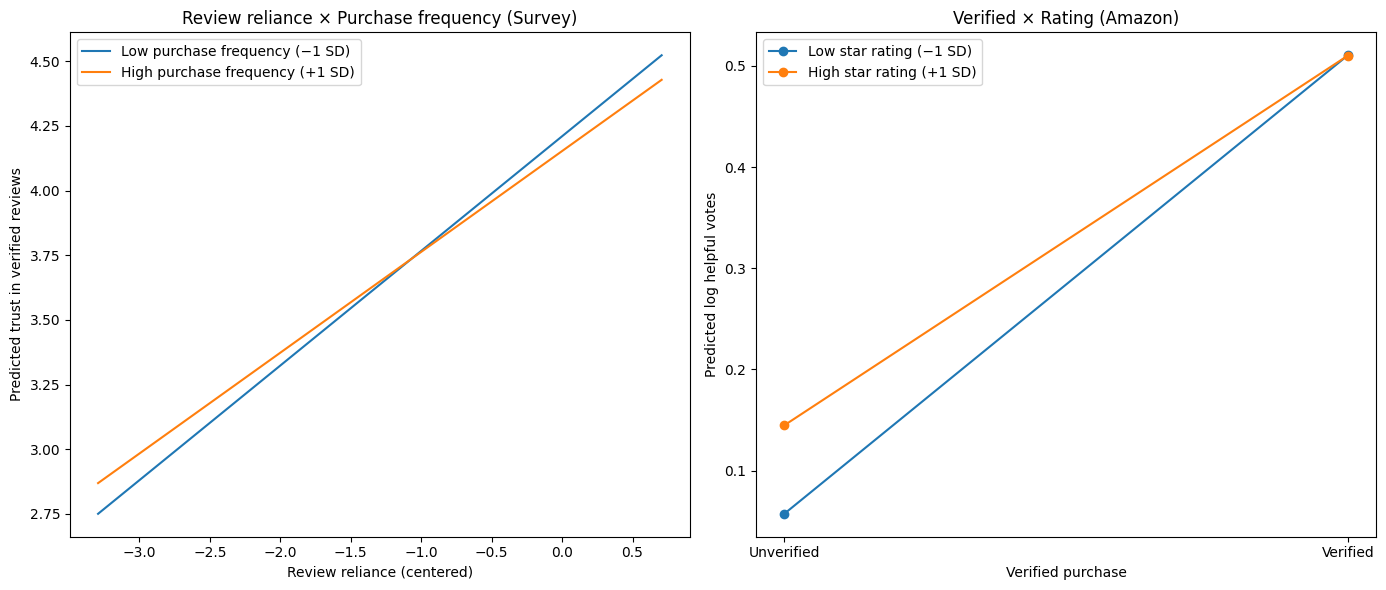


=== H2 (Survey) model summary (short) ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.1815      0.041    103.229      0.000       4.102       4.261
RR_c           0.4166      0.051      8.146      0.000       0.316       0.517
PF_c          -0.0296      0.045     -0.663      0.508      -0.118       0.058
RRxPF         -0.0277      0.046     -0.600      0.549      -0.118       0.063
Age_c         -0.0020      0.006     -0.333      0.740      -0.014       0.010

=== H2 (Amazon) model summary (short) ===
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.1011      0.021      4.820      0.000       0.060       0.142
verified_purchase     0.4092      0.032     12.841      0.000       0.347       0.472
rating_c         

In [ ]:
# ============================================================
# H2 Interaction Plots: Survey + Amazon (with robust modeling)
# ------------------------------------------------------------
# Files needed:
#   - Survey_Likert_Mapped_converted_v2.csv
#   - skincare_reviews_with_sentiment.csv
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# -----------------------------
# H2 (Survey): RR × PF (+ Age)
# -----------------------------
svy = pd.read_csv("Survey_Likert_Mapped_converted_v2.csv")[
    ["Trust verified reviews", "Review reliance", "Purchase_frequency_num", "Age_num"]
].dropna()

# Center predictors
svy["RR_c"]  = svy["Review reliance"] - svy["Review reliance"].mean()
svy["PF_c"]  = svy["Purchase_frequency_num"] - svy["Purchase_frequency_num"].mean()
svy["Age_c"] = svy["Age_num"] - svy["Age_num"].mean()

# Interaction
svy["RRxPF"] = svy["RR_c"] * svy["PF_c"]

# OLS (robust SE optional; here we fit plain for predictions)
y_svy = svy["Trust verified reviews"]
X_svy = sm.add_constant(svy[["RR_c", "PF_c", "RRxPF", "Age_c"]])
m_svy = sm.OLS(y_svy, X_svy).fit()

# Prediction grid: ±1 SD of moderator (PF_c), across RR range
rr_grid = np.linspace(svy["RR_c"].min(), svy["RR_c"].max(), 60)
pf_low  = svy["PF_c"].mean() - svy["PF_c"].std(ddof=1)
pf_high = svy["PF_c"].mean() + svy["PF_c"].std(ddof=1)

def predict_svy(pf_level):
    Xp = pd.DataFrame({
        "const": 1.0,
        "RR_c": rr_grid,
        "PF_c": pf_level,
        "RRxPF": rr_grid * pf_level,
        "Age_c": 0.0   # hold control at mean (0 because centered)
    })
    return m_svy.predict(Xp)

svy_pred_low  = predict_svy(pf_low)
svy_pred_high = predict_svy(pf_high)

# -----------------------------------------------
# H2 (Amazon): Verified × Rating + log(Length) ctl
# -----------------------------------------------
amz = pd.read_csv("skincare_reviews_with_sentiment.csv")

# Get review length from 'text' or 'combined_text'
text_col = "text" if "text" in amz.columns else ("combined_text" if "combined_text" in amz.columns else None)
if text_col is None:
    raise ValueError("No 'text' or 'combined_text' column found to compute review length.")
amz["review_length_words"] = amz[text_col].astype(str).str.split().apply(len)

# Clean/derive variables
amz["helpful_vote"]     = pd.to_numeric(amz["helpful_vote"], errors="coerce")
amz["rating"]           = pd.to_numeric(amz["rating"], errors="coerce")
amz["verified_purchase"] = amz["verified_purchase"].astype(str).str.lower().isin(
    ["1","true","yes","y"]).astype(int)

# Log transforms to address skew (DV & control)
amz["helpful_log"] = np.log1p(amz["helpful_vote"])
amz["length_log"]  = np.log1p(amz["review_length_words"])

# Drop missing
amz = amz[["helpful_log", "verified_purchase", "rating", "length_log"]].dropna().copy()

# Center moderator & control
amz["rating_c"]     = amz["rating"] - amz["rating"].mean()
amz["length_log_c"] = amz["length_log"] - amz["length_log"].mean()

# Interaction
amz["Verified_x_Rating"] = amz["verified_purchase"] * amz["rating_c"]

# Fit OLS (robust SEs for inference; plain fit okay for predictions)
y_amz = amz["helpful_log"]
X_amz = sm.add_constant(amz[["verified_purchase", "rating_c", "length_log_c", "Verified_x_Rating"]])
m_amz = sm.OLS(y_amz, X_amz).fit()

# Prediction at low vs high rating (±1 SD), holding control at mean (0)
r_low  = amz["rating_c"].mean() - amz["rating_c"].std(ddof=1)
r_high = amz["rating_c"].mean() + amz["rating_c"].std(ddof=1)
len_at_mean = 0.0  # centered

def predict_amz(r_level):
    Xp = pd.DataFrame({
        "const": 1.0,
        "verified_purchase": [0, 1],
        "rating_c": r_level,
        "length_log_c": len_at_mean,
        "Verified_x_Rating": [0 * r_level, 1 * r_level]
    })
    return m_amz.predict(Xp)

amz_pred_low  = predict_amz(r_low)   # two points: Unverified, Verified
amz_pred_high = predict_amz(r_high)

# -----------------------
# Plot both interactions
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Survey plot
axes[0].plot(rr_grid, svy_pred_low,  label="Low purchase frequency (−1 SD)")
axes[0].plot(rr_grid, svy_pred_high, label="High purchase frequency (+1 SD)")
axes[0].set_title("Review reliance × Purchase frequency (Survey)")
axes[0].set_xlabel("Review reliance (centered)")
axes[0].set_ylabel("Predicted trust in verified reviews")
axes[0].legend()

# Amazon plot
x_pos = [0, 1]  # 0=Unverified, 1=Verified
axes[1].plot(x_pos, amz_pred_low,  marker="o", label="Low star rating (−1 SD)")
axes[1].plot(x_pos, amz_pred_high, marker="o", label="High star rating (+1 SD)")
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(["Unverified", "Verified"])
axes[1].set_title("Verified × Rating (Amazon)")
axes[1].set_xlabel("Verified purchase")
axes[1].set_ylabel("Predicted log helpful votes")
axes[1].legend()

plt.tight_layout()
plt.show()

# Optional: print quick model summaries
print("\n=== H2 (Survey) model summary (short) ===")
print(m_svy.summary().tables[1])  # Coefs table only
print("\n=== H2 (Amazon) model summary (short) ===")
print(m_amz.summary().tables[1])


**Survey regression for H3**

=== H3 (Survey) — Trust detailed reviews ~ Review reliance × Purchase frequency + Age ===
Variable       B  Std. Error       t      p
   const  4.1481      0.0470 88.2656 0.0000
    RR_c  0.3703      0.0593  6.2405 0.0000
    PF_c -0.0233      0.0518 -0.4499 0.6531
   RRxPF  0.0312      0.0535  0.5827 0.5605
   Age_c  0.0032      0.0071  0.4463 0.6557

Model: R² = 0.135,  F = 11.798,  p = 6.45e-09

VIF:
Variable   VIF
    RR_c 1.122
    PF_c 1.164
   RRxPF 1.119
   Age_c 1.140


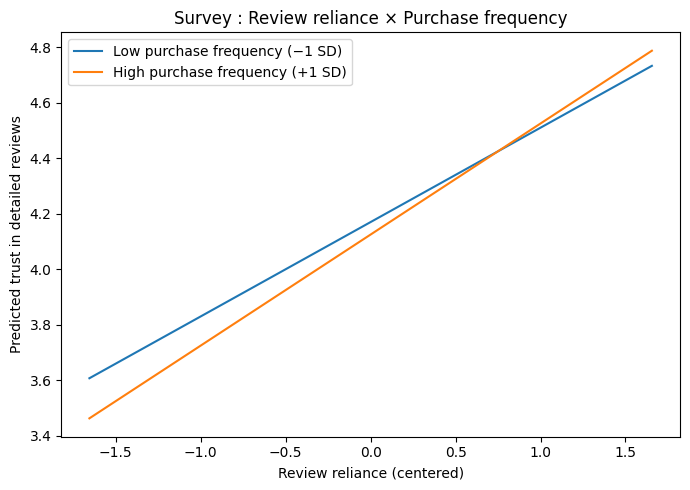

In [ ]:
# =====================================================
# H3 (Survey): Trust detailed reviews ~
#   Review reliance × Purchase frequency + Age control
# Produces regression output + an interaction plot
# Requires: Survey_Likert_Mapped_converted_v2.csv
# =====================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt

# ---------- Load & select ----------
survey_path = "Survey_Likert_Mapped_converted_v2.csv"
cols = ["Trust detailed reviews", "Review reliance",
        "Purchase_frequency_num", "Age_num"]
df = pd.read_csv(survey_path)[cols].dropna().copy()

# ---------- Mean-center (helps interpretation & VIF) ----------
df["RR_c"]   = df["Review reliance"] - df["Review reliance"].mean()
df["PF_c"]   = df["Purchase_frequency_num"] - df["Purchase_frequency_num"].mean()
df["Age_c"]  = df["Age_num"] - df["Age_num"].mean()

# Interaction term: Review reliance × Purchase frequency
df["RRxPF"]  = df["RR_c"] * df["PF_c"]

# ---------- Design matrices ----------
y = df["Trust detailed reviews"]
X = sm.add_constant(df[["RR_c", "PF_c", "RRxPF", "Age_c"]])

# ---------- Fit OLS ----------
model = sm.OLS(y, X).fit()

# ---------- Tidy results ----------
results = pd.DataFrame({
    "Variable": model.params.index,
    "B": model.params.values,
    "Std. Error": model.bse.values,
    "t": model.tvalues.values,
    "p": model.pvalues.values
}).round(4)

# ---------- VIF (exclude constant) ----------
vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif = vif[vif["Variable"] != "const"].round(3)

print("=== H3 (Survey) — Trust detailed reviews ~ Review reliance × Purchase frequency + Age ===")
print(results.to_string(index=False))
print("\nModel: R² = {:.3f},  F = {:.3f},  p = {:.3g}".format(model.rsquared, model.fvalue, model.f_pvalue))
print("\nVIF:")
print(vif.to_string(index=False))

# =====================================================
# Interaction plot (Low vs High Purchase Frequency)
# =====================================================
# Grid of IV values (review reliance, centered)
iv_grid = np.linspace(df["RR_c"].mean() - 2*df["RR_c"].std(ddof=1),
                      df["RR_c"].mean() + 2*df["RR_c"].std(ddof=1), 30)

# Define Low/High levels of the moderator (±1 SD)
pf_low  = df["PF_c"].mean() - df["PF_c"].std(ddof=1)
pf_high = df["PF_c"].mean() + df["PF_c"].std(ddof=1)

# Hold control at its mean (0 after centering)
age_at_mean = 0.0

# Build prediction rows for each moderator level
def predict_line(pf_level):
    Xp = pd.DataFrame({
        "const": 1.0,
        "RR_c": iv_grid,
        "PF_c": pf_level,
        "RRxPF": iv_grid * pf_level,
        "Age_c": age_at_mean
    })
    return model.predict(Xp)

y_low  = predict_line(pf_low)
y_high = predict_line(pf_high)

# Plot
plt.figure(figsize=(7,5))
plt.plot(iv_grid, y_low,  label="Low purchase frequency (−1 SD)")
plt.plot(iv_grid, y_high, label="High purchase frequency (+1 SD)")
plt.xlabel("Review reliance (centered)")
plt.ylabel("Predicted trust in detailed reviews")
plt.title("Survey : Review reliance × Purchase frequency")
plt.legend()
plt.tight_layout()
plt.savefig("H3_Survey_Interaction.png", dpi=300)
plt.show()  # <- ensures the figure is visible when you run the script


**H3 - Regressioon Amazon data**

=== H3 (Amazon) — log(helpful votes) ~ Verified × log(Length) + Rating (control) ===
         Variable      B  Std. Error (HC3)       t      p
            const 0.1464            0.0171  8.5485 0.0000
verified_purchase 0.3907            0.0348 11.2156 0.0000
     length_log_c 0.1364            0.0221  6.1584 0.0000
         rating_c 0.0140            0.0124  1.1333 0.2571
     Ver_x_LenLog 0.0998            0.0303  3.2915 0.0010

Model fit: R² = 0.117,  adj. R² = 0.115,  F = 42.821,  p(model) = 1.62e-34

VIF:
         Variable   VIF
verified_purchase 1.380
     length_log_c 2.418
         rating_c 1.019
     Ver_x_LenLog 2.807

Avg VIF = 1.906,  Max VIF = 2.807


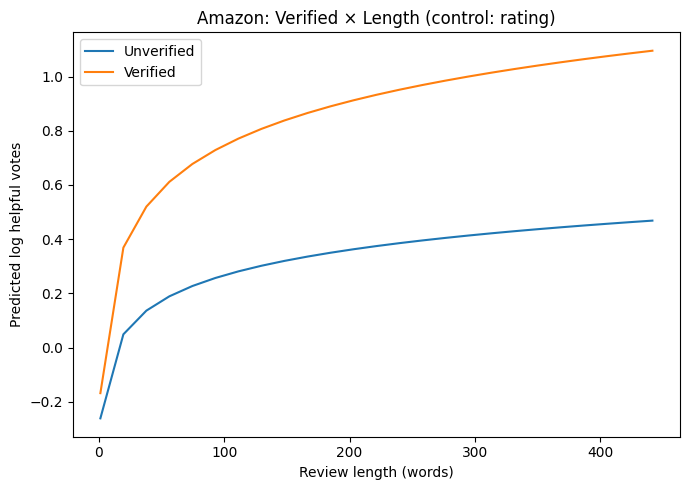

In [ ]:
# ============================================================
# H3 (Amazon) — log(helpful votes) ~ Verified × log(Length) + Rating (control)
# DV : log(1 + helpful_vote)
# IV : verified_purchase (0/1)
# Mod: log(1 + review_length_words), mean-centered
# Ctl: rating (star rating), mean-centered
# File: skincare_reviews_with_sentiment.csv
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt

# ---------- Load data ----------
df = pd.read_csv("skincare_reviews_with_sentiment.csv")

# Helpful votes (DV)
df["helpful_vote"] = pd.to_numeric(df["helpful_vote"], errors="coerce")

# Verified purchase (IV, binary 0/1)
df["verified_purchase"] = df["verified_purchase"].astype(str).str.lower().isin(
    ["1", "true", "yes", "y"]
).astype(int)

# Rating (control)
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

# Review length (moderator) — from 'text' or 'combined_text'
text_col = "text" if "text" in df.columns else ("combined_text" if "combined_text" in df.columns else None)
if text_col is None:
    raise ValueError("No 'text' or 'combined_text' column found to compute review_length_words.")
df["review_length_words"] = df[text_col].astype(str).str.split().apply(len)

# Keep relevant cols and drop NA
df = df[["helpful_vote", "verified_purchase", "rating", "review_length_words"]].dropna().copy()

# ---------- Transform skewed variables ----------
df["helpful_log"] = np.log1p(df["helpful_vote"])           # DV
df["length_log"]  = np.log1p(df["review_length_words"])    # Moderator

# ---------- Mean-center moderator & control ----------
df["length_log_c"] = df["length_log"] - df["length_log"].mean()
df["rating_c"]     = df["rating"] - df["rating"].mean()

# Interaction: Verified × log(Length_c)
df["Ver_x_LenLog"] = df["verified_purchase"] * df["length_log_c"]

# ---------- Regression (HC3 robust SEs) ----------
y = df["helpful_log"]
X = df[["verified_purchase", "length_log_c", "rating_c", "Ver_x_LenLog"]]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit(cov_type="HC3")

# ---------- Results ----------
results = pd.DataFrame({
    "Variable": model.params.index,
    "B": model.params.values,
    "Std. Error (HC3)": model.bse.values,
    "t": model.tvalues.values,
    "p": model.pvalues.values
}).round(4)

# ---------- VIF (predictors only) ----------
X_no_const = X.drop(columns=["const"])
vif_vals = [variance_inflation_factor(X_no_const.values, i) for i in range(X_no_const.shape[1])]
vif = pd.DataFrame({"Variable": X_no_const.columns, "VIF": np.round(vif_vals, 3)})
vif_max = float(np.nanmax(vif["VIF"]))
vif_avg = float(np.nanmean(vif["VIF"]))

print("=== H3 (Amazon) — log(helpful votes) ~ Verified × log(Length) + Rating (control) ===")
print(results.to_string(index=False))
print("\nModel fit: R² = {:.3f},  adj. R² = {:.3f},  F = {:.3f},  p(model) = {:.3g}".format(
    model.rsquared, model.rsquared_adj, model.fvalue, model.f_pvalue
))
print("\nVIF:")
print(vif.to_string(index=False))
print(f"\nAvg VIF = {vif_avg:.3f},  Max VIF = {vif_max:.3f}")

# ---------- Interaction plot ----------
# Show x-axis in words (not logs) for interpretability
PLOT = True
if PLOT:
    # Build a grid over the central 1–99% of review lengths
    lo_w, hi_w = np.percentile(df["review_length_words"], [1, 99])
    words_grid = np.linspace(lo_w, hi_w, 25)

    # Convert to centered log-length for prediction
    len_log_grid = np.log1p(words_grid)
    len_log_c_grid = len_log_grid - df["length_log"].mean()

    # Hold control (rating) at its mean (0 after centering)
    rating_at_mean = 0.0

    def predict_line(verified_level):
        Xp = pd.DataFrame({
            "const": 1.0,
            "verified_purchase": verified_level,
            "length_log_c": len_log_c_grid,
            "rating_c": rating_at_mean,
            "Ver_x_LenLog": verified_level * len_log_c_grid
        })
        return model.predict(Xp)

    y_unverified = predict_line(0)
    y_verified   = predict_line(1)

    plt.figure(figsize=(7,5))
    plt.plot(words_grid, y_unverified, label="Unverified")
    plt.plot(words_grid, y_verified,   label="Verified")
    plt.xlabel("Review length (words)")
    plt.ylabel("Predicted log helpful votes")
    plt.title("Amazon: Verified × Length (control: rating)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("H3_Amazon_Verified_x_LogLength.png", dpi=300)
    # plt.show()



**H4 - negativity bias - Survey**

=== H4 (Survey) — Negativity bias model ===
   Variable       B  Std. Error       t      p
      const  3.7919      0.0463 81.8256 0.0000
TrustCred_c  0.2154      0.0636  3.3860 0.0008
   Relian_c  0.4451      0.0599  7.4304 0.0000
   CredxRel  0.0289      0.0457  0.6318 0.5280
      Age_c -0.0283      0.0067 -4.2187 0.0000

Model: R²=0.299, F=32.154, p=2.5e-22

VIF:
   Variable   VIF
TrustCred_c 1.229
   Relian_c 1.193
   CredxRel 1.232
      Age_c 1.070


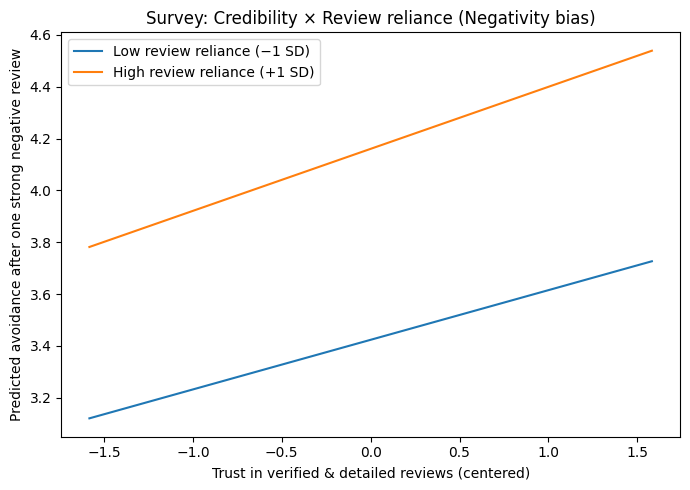

In [ ]:
# ============================================================
# H4 (Survey): Negativity bias
# DV : Avoidance after negative review
# IV : Trust in credible reviews  (use "Trust verified and detailed.")
# Mod: Review reliance
# Ctl: Age_num  (optional: Purchase_frequency_num)
# File needed: Survey_Likert_Mapped_converted_v2.csv
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt

# ---------------- Load data ----------------
path = "Survey_Likert_Mapped_converted_v2.csv"
cols = [
    "Avoidance after negative review",
    "Trust verified and detailed.",   # <- IV (you can swap to 'Trust verified reviews' or 'Trust detailed reviews')
    "Review reliance",
    "Age_num",
    # "Purchase_frequency_num",       # <- optionally include as an extra control
]
df = pd.read_csv(path)[cols].dropna().copy()

# Rename for convenience
df = df.rename(columns={
    "Avoidance after negative review": "Avoid",
    "Trust verified and detailed.": "TrustCred",  # IV
    "Review reliance": "Relian",
    "Age_num": "Age"
})

# ---------------- Center variables ----------------
df["TrustCred_c"] = df["TrustCred"] - df["TrustCred"].mean()
df["Relian_c"]    = df["Relian"]    - df["Relian"].mean()
df["Age_c"]       = df["Age"]       - df["Age"].mean()
# If you add purchase frequency as a control:
# df["PF_c"] = df["Purchase_frequency_num"] - df["Purchase_frequency_num"].mean()

# Interaction: credibility × reliance
df["CredxRel"] = df["TrustCred_c"] * df["Relian_c"]

# ---------------- Regression ----------------
y = df["Avoid"]
X = df[["TrustCred_c", "Relian_c", "CredxRel", "Age_c"]]  # add "PF_c" here if you include it
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

# ---------------- Results table ----------------
results = pd.DataFrame({
    "Variable": model.params.index,
    "B": model.params.values,
    "Std. Error": model.bse.values,
    "t": model.tvalues.values,
    "p": model.pvalues.values
}).round(4)

# ---------------- VIF (predictors only) ----------------
vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif = vif[vif["Variable"] != "const"].round(3)

print("=== H4 (Survey) — Negativity bias model ===")
print(results.to_string(index=False))
print("\nModel: R²={:.3f}, F={:.3f}, p={:.3g}".format(model.rsquared, model.fvalue, model.f_pvalue))
print("\nVIF:")
print(vif.to_string(index=False))

# ============================================================
# Interaction plot: Low vs High Review reliance (±1 SD)
# ============================================================
iv_grid = np.linspace(df["TrustCred_c"].mean() - 2*df["TrustCred_c"].std(ddof=1),
                      df["TrustCred_c"].mean() + 2*df["TrustCred_c"].std(ddof=1), 30)

rel_low  = df["Relian_c"].mean() - df["Relian_c"].std(ddof=1)
rel_high = df["Relian_c"].mean() + df["Relian_c"].std(ddof=1)

def predict_line(rel_level):
    Xp = pd.DataFrame({
        "const": 1.0,
        "TrustCred_c": iv_grid,
        "Relian_c": rel_level,
        "CredxRel": iv_grid * rel_level,
        "Age_c": 0.0,
        # "PF_c": 0.0,  # if you include purchase frequency, hold at mean (0 after centering)
    })
    return model.predict(Xp)

y_low  = predict_line(rel_low)
y_high = predict_line(rel_high)

plt.figure(figsize=(7,5))
plt.plot(iv_grid, y_low,  label="Low review reliance (−1 SD)")
plt.plot(iv_grid, y_high, label="High review reliance (+1 SD)")
plt.xlabel("Trust in verified & detailed reviews (centered)")
plt.ylabel("Predicted avoidance after one strong negative review")
plt.title("Survey: Credibility × Review reliance (Negativity bias)")
plt.legend()
plt.tight_layout()
plt.savefig("H4_Survey_NegativityBias_Interaction.png", dpi=300)
plt.show()


**H4 regression Amazon data**

=== H4 (Amazon) — log(helpful) ~ Neg × Len × Verified + Rating ===
         Variable       B  Std. Error       t      p
            const  0.2018      0.0172 11.7628 0.0000
            Neg_c  0.0181      0.0221  0.8158 0.4146
            Len_c  0.0010      0.0003  3.1575 0.0016
verified_purchase  0.3973      0.0480  8.2848 0.0000
         Rating_c  0.0122      0.0169  0.7223 0.4701
        Neg_x_Len -0.0001      0.0003 -0.4344 0.6640
        Neg_x_Ver -0.0633      0.0588 -1.0764 0.2817
        Len_x_Ver  0.0044      0.0009  5.0263 0.0000
  Neg_x_Len_x_Ver -0.0015      0.0011 -1.2981 0.1942

Model fit: R²=0.115, adj. R²=0.112, F=10.193, p(model)=4.79e-14

Avg VIF = 2.248, Max VIF = 3.745
         Variable   VIF
            Neg_c 3.152
            Len_c 1.480
verified_purchase 1.489
         Rating_c 1.870
        Neg_x_Len 1.732
        Neg_x_Ver 3.745
        Len_x_Ver 1.754
  Neg_x_Len_x_Ver 2.761


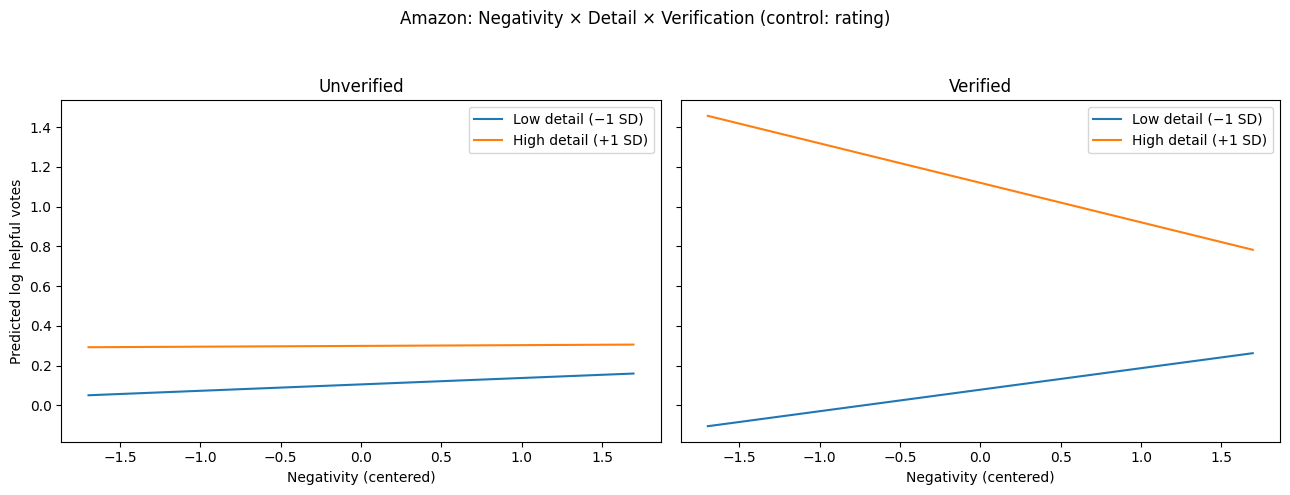

In [ ]:
# ============================================================
# H4 (Amazon) — Negativity bias under credible conditions
# DV : log(helpful_vote + 1)   [log-transformed for skewness]
# IV : NegSent = -Sentiment_score (higher = more negative)
# Moderators : Review length (detail), Verified purchase (0/1)
# Control : Rating
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt

# ---------- Load Data ----------
df = pd.read_csv("skincare_reviews_with_sentiment.csv")

# Variables
df["helpful_vote"] = pd.to_numeric(df["helpful_vote"], errors="coerce")
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["Sentiment_score"] = pd.to_numeric(df["Sentiment_score"], errors="coerce")

# Verified (0/1)
df["verified_purchase"] = df["verified_purchase"].astype(str).str.lower().isin(
    ["1", "true", "yes", "y"]
).astype(int)

# Review length (words)
text_col = "text" if "text" in df.columns else "combined_text"
df["review_length_words"] = df[text_col].astype(str).str.split().apply(len)

# Keep relevant
df = df[["helpful_vote","rating","Sentiment_score","verified_purchase","review_length_words"]].dropna().copy()

# ---------- Transform + Center ----------
df["log_helpful"] = np.log1p(df["helpful_vote"])   # DV
df["NegSent"] = -df["Sentiment_score"]             # IV (higher = more negative)

# Center
df["Neg_c"]    = df["NegSent"] - df["NegSent"].mean()
df["Len_c"]    = df["review_length_words"] - df["review_length_words"].mean()
df["Rating_c"] = df["rating"] - df["rating"].mean()

# Interactions
df["Neg_x_Len"]   = df["Neg_c"] * df["Len_c"]
df["Neg_x_Ver"]   = df["Neg_c"] * df["verified_purchase"]
df["Len_x_Ver"]   = df["Len_c"] * df["verified_purchase"]
df["Neg_x_Len_x_Ver"] = df["Neg_c"] * df["Len_c"] * df["verified_purchase"]

# ---------- Regression ----------
y = df["log_helpful"]
X = df[["Neg_c","Len_c","verified_purchase","Rating_c","Neg_x_Len","Neg_x_Ver","Len_x_Ver","Neg_x_Len_x_Ver"]]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit(cov_type="HC3")   # robust SE

# ---------- Results ----------
results = pd.DataFrame({
    "Variable": model.params.index,
    "B": model.params.values,
    "Std. Error": model.bse.values,
    "t": model.tvalues.values,
    "p": model.pvalues.values
}).round(4)

print("=== H4 (Amazon) — log(helpful) ~ Neg × Len × Verified + Rating ===")
print(results.to_string(index=False))
print("\nModel fit: R²={:.3f}, adj. R²={:.3f}, F={:.3f}, p(model)={:.2e}".format(
    model.rsquared, model.rsquared_adj, model.fvalue, model.f_pvalue))

# ---------- VIF ----------
vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif = vif[vif["Variable"] != "const"].round(3)
print("\nAvg VIF = {:.3f}, Max VIF = {:.3f}".format(vif["VIF"].mean(), vif["VIF"].max()))
print(vif.to_string(index=False))

# ---------- Interaction Plot ----------
# Grid for Negativity
neg_grid = np.linspace(df["Neg_c"].mean() - 2*df["Neg_c"].std(ddof=1),
                       df["Neg_c"].mean() + 2*df["Neg_c"].std(ddof=1), 40)

# Low/High Detail (±1 SD)
len_low  = df["Len_c"].mean() - df["Len_c"].std(ddof=1)
len_high = df["Len_c"].mean() + df["Len_c"].std(ddof=1)
rating_at_mean = 0.0

def predict_line(v_verified, length_level):
    Xp = pd.DataFrame({
        "const": 1.0,
        "Neg_c": neg_grid,
        "Len_c": length_level,
        "verified_purchase": v_verified,
        "Rating_c": rating_at_mean,
        "Neg_x_Len": neg_grid * length_level,
        "Neg_x_Ver": neg_grid * v_verified,
        "Len_x_Ver": length_level * v_verified,
        "Neg_x_Len_x_Ver": neg_grid * length_level * v_verified,
    })
    return model.predict(Xp)

# Predictions
y_unver_low  = predict_line(0, len_low)
y_unver_high = predict_line(0, len_high)
y_ver_low    = predict_line(1, len_low)
y_ver_high   = predict_line(1, len_high)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13,5), sharey=True)

# Unverified
axes[0].plot(neg_grid, y_unver_low,  label="Low detail (−1 SD)")
axes[0].plot(neg_grid, y_unver_high, label="High detail (+1 SD)")
axes[0].set_title("Unverified")
axes[0].set_xlabel("Negativity (centered)")
axes[0].set_ylabel("Predicted log helpful votes")
axes[0].legend()

# Verified
axes[1].plot(neg_grid, y_ver_low,  label="Low detail (−1 SD)")
axes[1].plot(neg_grid, y_ver_high, label="High detail (+1 SD)")
axes[1].set_title("Verified")
axes[1].set_xlabel("Negativity (centered)")
axes[1].legend()

plt.suptitle("Amazon: Negativity × Detail × Verification (control: rating)")
plt.tight_layout(rect=[0,0,1,0.94])
plt.savefig("H4_Amazon_Interaction.png", dpi=300)
plt.show()



**H1 - Sentiment and rating are they consistent**

In [ ]:
# ============================================================
# H1 (Amazon): Do positive-sounding reviews map to higher stars?
# DV: rating
# IV: Sentiment_score (higher = more positive)
# Controls: review_length_words, verified_purchase (0/1)
# Output: tidy regression table + VIF (Avg/Max) and an Excel file
# File needed: skincare_reviews_with_sentiment.csv
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ---------- Load data ----------
df = pd.read_csv("skincare_reviews_with_sentiment.csv")

# Basic checks
need_cols = ["rating", "Sentiment_score"]
for c in need_cols:
    if c not in df.columns:
        raise ValueError(f"Missing required column: {c}")

# Rating (DV) and sentiment (IV)
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["Sentiment_score"] = pd.to_numeric(df["Sentiment_score"], errors="coerce")

# Verified (control) -> binary 0/1 if present, else fill with 0
if "verified_purchase" in df.columns:
    df["verified_purchase"] = (
        df["verified_purchase"].astype(str).str.lower().isin(["1", "true", "yes", "y"]).astype(int)
    )
else:
    df["verified_purchase"] = 0

# Review length (control) from 'text' or 'combined_text' if present
if "text" in df.columns:
    text_col = "text"
elif "combined_text" in df.columns:
    text_col = "combined_text"
else:
    text_col = None

if text_col:
    df["review_length_words"] = df[text_col].astype(str).str.split().apply(len)
else:
    # If no text column exists, fill zeros (model still runs but without variation in this control)
    df["review_length_words"] = 0

# Keep relevant rows
df = df[["rating", "Sentiment_score", "review_length_words", "verified_purchase"]].dropna().copy()

# ---------- Center continuous predictors (helps interpretability & VIF) ----------
df["Sentiment_c"] = df["Sentiment_score"] - df["Sentiment_score"].mean()
df["Length_c"]    = df["review_length_words"] - df["review_length_words"].mean()
# verified_purchase is 0/1; keep uncentered for interpretability

# ---------- Design matrices ----------
y = df["rating"]
X = pd.DataFrame({
    "Sentiment_c": df["Sentiment_c"],
    "Length_c": df["Length_c"],
    "verified_purchase": df["verified_purchase"]
})
X = sm.add_constant(X)

# ---------- Fit OLS with robust (HC3) SE ----------
model = sm.OLS(y, X).fit(cov_type="HC3")

# ---------- Tidy results table ----------
results = pd.DataFrame({
    "Variable": model.params.index,
    "B": model.params.values,
    "Std. Error (HC3)": model.bse.values,
    "t": model.tvalues.values,
    "p": model.pvalues.values
}).round(4)

# ---------- VIF (predictors only) ----------
vif_tbl = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif_tbl = vif_tbl[vif_tbl["Variable"] != "const"].round(3)
avg_vif = float(vif_tbl["VIF"].mean()) if not vif_tbl.empty else np.nan
max_vif = float(vif_tbl["VIF"].max()) if not vif_tbl.empty else np.nan

# ---------- Print outputs ----------
print("=== H1 (Amazon) — rating ~ sentiment + length + verified ===")
print(results.to_string(index=False))
print("\nModel fit: R² = {:.3f},  adj. R² = {:.3f},  F = {:.3f},  p(model) = {:.2g}".format(
    model.rsquared, model.rsquared_adj, model.fvalue, model.f_pvalue
))
print("\nVIF:")
print(vif_tbl.to_string(index=False))
print(f"\nAvg VIF = {avg_vif:.3f},  Max VIF = {max_vif:.3f}")

# ---------- Save to Excel ----------
out_xlsx = "H1_Amazon_Sentiment_Rating.xlsx"
with pd.ExcelWriter(out_xlsx, engine="xlsxwriter") as writer:
    results.to_excel(writer, index=False, sheet_name="Coefficients")
    vif_tbl.to_excel(writer, index=False, sheet_name="VIF")
    # Add a small metadata sheet
    meta = pd.DataFrame({
        "Note": [
            "DV: rating",
            "IV: Sentiment_score (centered)",
            "Controls: review_length_words (centered), verified_purchase (0/1)",
            "SEs: Robust HC3"h
        ]
    })
    meta.to_excel(writer, index=False, sheet_name="Meta")

print(f"\nSaved Excel: {out_xlsx}")

# ---------- Optional: also run a simple bivariate model for reference ----------
# (Uncomment if you want to see the pure sentiment->rating slope without controls)
# X_simple = sm.add_constant(df[["Sentiment_c"]])
# model_simple = sm.OLS(y, X_simple).fit(cov_type="HC3")
# print("\n--- H1 Bivariate (rating ~ sentiment) ---")
# print(model_simple.summary())

=== H1 (Amazon) — rating ~ sentiment + length + verified ===
         Variable       B  Std. Error (HC3)        t      p
            const  4.2184            0.0283 149.1646 0.0000
      Sentiment_c  0.9274            0.0309  30.0097 0.0000
         Length_c  0.0008            0.0002   4.0830 0.0000
verified_purchase -0.0595            0.0431  -1.3801 0.1676

Model fit: R² = 0.441,  adj. R² = 0.440,  F = 300.468,  p(model) = 4.1e-161

VIF:
         Variable   VIF
      Sentiment_c 1.015
         Length_c 1.217
verified_purchase 1.220

Avg VIF = 1.151,  Max VIF = 1.220

Saved Excel: H1_Amazon_Sentiment_Rating.xlsx
